# A fine-granularity reference for single van der Pol steps

`RK_Truth` stores whole trajectories on a coarse grid — enough to look at laps,
too coarse to say what happens *inside* one learned step. The learned steps used
elsewhere in this project cover `dt = 0.8` at a time (about a tenth of a lap), and
a later experiment (a network that returns learned Runge-Kutta **weights**) needs
the true solution sampled densely *within* one such step, to supervise against.

This notebook exercises the generator in `mini_trajectories.py`, measures that it
is correct, draws it, and writes one stored demonstration slice. **The generator
is the product** — `data/fine_steps.npz` is only a fixed example of what it makes;
later experiments call the generator with their own starts and `dt`.

Everything is float64 and seeded. It imports `RK_Truth` (the verified order-6
integrator and the equation) and the project's Latin-hypercube sampler by path,
copying nothing and writing nothing outside this folder.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str((HERE / ".." / "discrete_time_network").resolve()))
sys.path.insert(0, str((HERE / ".." / "RK_Truth").resolve()))

import mini_trajectories as mt          # the generator (this folder)
from model import training_states       # seeded Latin-hypercube sampler over the rectangle
from trajectories import NAMED_STARTS   # the 8 labelled starting states

DATA = HERE / "data"; DATA.mkdir(exist_ok=True)
FIGS = HERE / "figures"; FIGS.mkdir(exist_ok=True)

DT = 0.8                 # the learned-step size used elsewhere in the project
np.set_printoptions(precision=12, suppress=False)
print("fine reference step h =", mt.H_FINE, "   mu =", mt.MU, "   dt =", DT)

fine reference step h = 0.0001    mu = 1.0    dt = 0.8


## 1. The generator

`dense_step(y0s, dt, h, store_every)` marches the order-6 integrator from each
start with a fine step `h` and stores every `store_every`-th sub-step, giving the
solution at every stored sub-time on `[0, dt]`. With `h = 1e-4` and
`store_every = 10` the stored spacing is `1e-3` — 801 points across one `dt = 0.8`
step.

In [2]:
labels = list(NAMED_STARTS)
named = np.array([NAMED_STARTS[k] for k in labels], dtype=float)

t, Y, h_used = mt.dense_step(named, DT, h=1e-4, store_every=10)
print("stored sub-times t:", t.shape, " from", t[0], "to", t[-1],
      " spacing", np.round(np.diff(t)[:3], 6))
print("solution Y (n_stored, n_starts, 2):", Y.shape, " step actually used:", h_used)

stored sub-times t: (801,)  from 0.0 to 0.8  spacing [0.001 0.001 0.001]
solution Y (n_stored, n_starts, 2): (801, 8, 2)  step actually used: 0.0001


`solution_at_times(y0s, times, h)` returns the solution at an arbitrary
*ascending* list of interior times, each reached exactly by integrating
segment-to-segment with `integrate_to` — **no interpolation**. This is how the
later experiment will read the truth at its Gauss node times, which fall between
any fixed grid. Here are the 3-stage Gauss-Legendre node times of one step.

In [3]:
nodes, _ = np.polynomial.legendre.leggauss(3)
node_c = 0.5 * (nodes + 1.0)                 # Gauss nodes mapped to [0, 1]
node_t = DT * node_c                         # ... and to [0, dt]
Y_nodes = mt.solution_at_times(named, node_t, h=1e-4)
print("Gauss node fractions:", np.round(node_c, 6))
print("states at node times (n_nodes, n_starts, 2):", Y_nodes.shape)

Gauss node fractions: [0.112702 0.5      0.887298]
states at node times (n_nodes, n_starts, 2): (3, 8, 2)


### Figure — a few mini-trajectories, with the dense sampling visible

Four of the named starts, resolved inside one `dt = 0.8` step. Left: `y1` against
time, the fine grid drawn as dots (every 25th of the 801 stored points) so the
density is visible, with the three Gauss node times marked. Right: the same arcs
in the phase plane, with the Gauss-node states (stars) — the interior samples the
coarse reference does not carry.

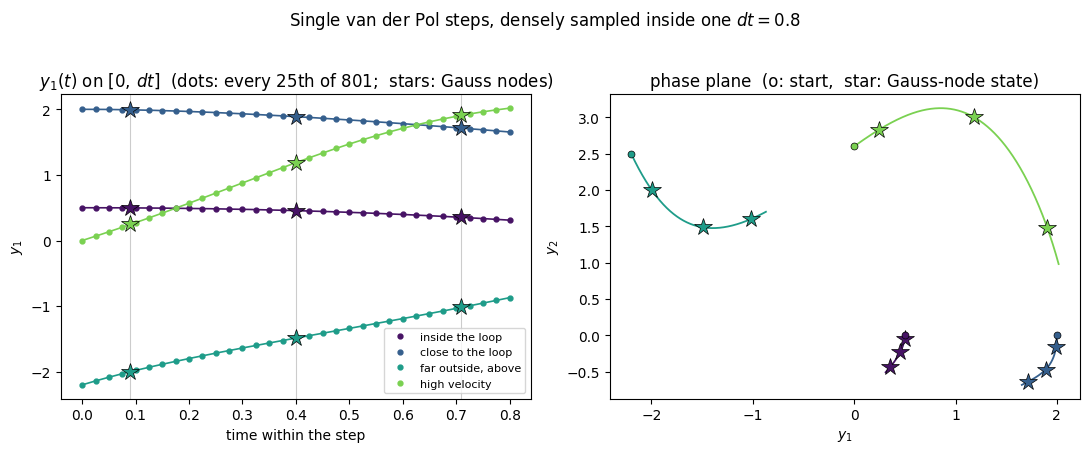

In [4]:
show = ["inside the loop", "close to the loop", "far outside, above", "high velocity"]
idx = [labels.index(s) for s in show]
colors = plt.cm.viridis(np.linspace(0.05, 0.8, len(idx)))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.4))
sub = slice(None, None, 25)
for c, k, name in zip(colors, idx, show):
    axL.plot(t, Y[:, k, 0], "-", color=c, lw=1.2, zorder=1)
    axL.plot(t[sub], Y[sub, k, 0], "o", color=c, ms=3.5, zorder=2, label=name)
    axL.plot(node_t, Y_nodes[:, k, 0], "*", color=c, ms=13,
             mec="k", mew=0.5, zorder=3)
    axR.plot(Y[:, k, 0], Y[:, k, 1], "-", color=c, lw=1.3)
    axR.plot(Y_nodes[:, k, 0], Y_nodes[:, k, 1], "*", color=c, ms=13,
             mec="k", mew=0.5)
    axR.plot(Y[0, k, 0], Y[0, k, 1], "o", color=c, ms=5, mec="k", mew=0.5)
for x in node_t:
    axL.axvline(x, color="0.8", lw=0.8, zorder=0)
axL.set_xlabel("time within the step"); axL.set_ylabel("$y_1$")
axL.set_title("$y_1(t)$ on $[0,\\,dt]$  (dots: every 25th of 801;  stars: Gauss nodes)")
axL.legend(fontsize=8, loc="best")
axR.set_xlabel("$y_1$"); axR.set_ylabel("$y_2$")
axR.set_title("phase plane  (o: start,  star: Gauss-node state)")
fig.suptitle("Single van der Pol steps, densely sampled inside one $dt=0.8$", y=1.02)
fig.tight_layout()
fig.savefig(FIGS / "mini_trajectories.png", dpi=130, bbox_inches="tight")
plt.show()

## 2. Verification — measured, not asserted

Three numbers, all over the **same 100-state Latin-hypercube sample** of the
training rectangle (`training_states(100, seed=1)`), all at the endpoint of one
`dt = 0.8` step.

1. **Halving.** The endpoint at `h = 1e-4` vs `h = 5e-5`. The order-6 scheme's own
   error at this step is ~`1e-24` per unit time, far below what double precision
   holds, so any difference here is pure double-precision roundoff.
2. **Consistency.** The endpoint at `h = 1e-4` vs the standard reference step
   `h = 1e-3`. Same story — the two should agree to roundoff.
3. **No-interpolation path agrees with the dense grid.** Landing
   `solution_at_times` exactly on a stored sub-time must reproduce the
   `dense_step` value there.

Endpoints are computed through `solution_at_times`, so this exercises that path
directly.

In [5]:
verify_states = training_states(100, seed=1)

E_fine  = mt.solution_at_times(verify_states, [DT], h=1e-4)[0]
E_finer = mt.solution_at_times(verify_states, [DT], h=5e-5)[0]
E_std   = mt.solution_at_times(verify_states, [DT], h=1e-3)[0]

halving = np.linalg.norm(E_fine - E_finer, axis=1)
consist = np.linalg.norm(E_fine - E_std,   axis=1)
halving_max, consistency_max = float(halving.max()), float(consist.max())

# no-interpolation path vs the dense grid, at an on-grid time
tg, Yg, _ = mt.dense_step(verify_states, DT, h=1e-4, store_every=10)
j = int(np.argmin(np.abs(tg - 0.4)))
seg = mt.solution_at_times(verify_states, [tg[j]], h=1e-4)[0]
seg_vs_dense_max = float(np.abs(seg - Yg[j]).max())

eps = np.finfo(float).eps
print(f"halving      max |E(1e-4) - E(5e-5)|  = {halving_max:.3e}   (median {np.median(halving):.1e})")
print(f"consistency  max |E(1e-4) - E(1e-3)|  = {consistency_max:.3e}   (median {np.median(consist):.1e})")
print(f"segment vs dense grid at t={tg[j]:.3f}   = {seg_vs_dense_max:.1e}")
print(f"machine epsilon                        = {eps:.3e}")
assert halving_max < 1e-11 and consistency_max < 1e-11, "endpoints disagree by more than roundoff"
print("\\nboth agree to roundoff -> at h = 1e-4 the fine step is not a question.")

halving      max |E(1e-4) - E(5e-5)|  = 4.353e-14   (median 1.0e-14)
consistency  max |E(1e-4) - E(1e-3)|  = 3.736e-14   (median 6.7e-15)
segment vs dense grid at t=0.400   = 0.0e+00
machine epsilon                        = 2.220e-16
\nboth agree to roundoff -> at h = 1e-4 the fine step is not a question.


### Figure — the verification numbers

The two endpoint disagreements against the scale of double-precision roundoff over
this many steps. Both sit on the floor; a finer step buys nothing.

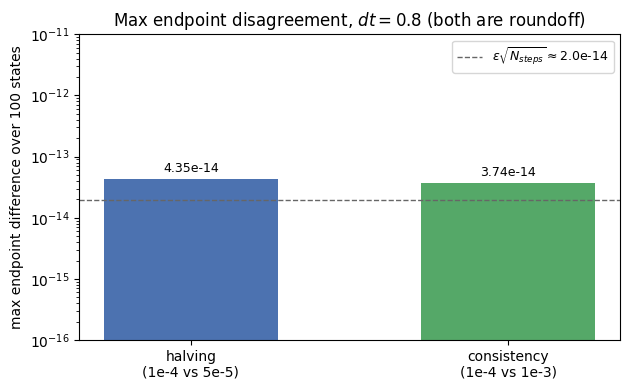

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
names = ["halving\n(1e-4 vs 5e-5)", "consistency\n(1e-4 vs 1e-3)"]
vals = [halving_max, consistency_max]
bars = ax.bar(names, vals, color=["#4C72B0", "#55A868"], width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.15, f"{v:.2e}",
            ha="center", va="bottom", fontsize=9)
roundoff = eps * np.sqrt(DT / 1e-4)          # ~ eps * sqrt(#steps): the accumulation scale
ax.axhline(roundoff, color="0.4", ls="--", lw=1,
           label=f"$\\epsilon\\sqrt{{N_{{steps}}}}\\approx${roundoff:.1e}")
ax.set_yscale("log"); ax.set_ylabel("max endpoint difference over 100 states")
ax.set_ylim(1e-16, 1e-11)
ax.set_title("Max endpoint disagreement, $dt=0.8$ (both are roundoff)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGS / "verification_numbers.png", dpi=130, bbox_inches="tight")
plt.show()

## 3. A stored demonstration slice — `data/fine_steps.npz`

A fixed example of the generator's output, for eyeballing and quick reuse: the
dense solution on `[0, 0.8]` at spacing `1e-3` (801 points) for the **8 named
starts plus a 256-state Latin-hypercube sample** (`seed = 7`). Stored with the
starts, the sub-times, the step used, and `mu`. A small `metadata.csv` records the
facts. **This file is a demonstration, not the deliverable** — later experiments
call `mini_trajectories.dense_step` / `solution_at_times` with their own starts
and `dt`.

In [7]:
named_labels = list(NAMED_STARTS)
named_y0 = np.array([NAMED_STARTS[k] for k in named_labels], dtype=float)
sampled_y0 = training_states(256, seed=7)
y0 = np.vstack([named_y0, sampled_y0])
kind = np.array(["named"] * len(named_y0) + ["lhc_seed7"] * len(sampled_y0), dtype=object)
start_label = np.array(named_labels + [f"lhc_{i:03d}" for i in range(len(sampled_y0))], dtype=object)

t_ds, Y_ds, h_ds = mt.dense_step(y0, DT, h=1e-4, store_every=10)
print("demonstration dataset  Y (n_times, n_starts, 2):", Y_ds.shape,
      "  n_named =", len(named_y0), "  n_sampled =", len(sampled_y0))

np.savez_compressed(
    DATA / "fine_steps.npz",
    t=t_ds, Y=Y_ds, y0=y0, kind=kind, start_label=start_label,
    h=h_ds, dt=DT, mu=mt.MU,
)
size_mb = (DATA / "fine_steps.npz").stat().st_size / 1e6
print(f"wrote data/fine_steps.npz  ({size_mb:.2f} MB compressed)")

demonstration dataset  Y (n_times, n_starts, 2): (801, 264, 2)   n_named = 8   n_sampled = 256


wrote data/fine_steps.npz  (3.28 MB compressed)


In [8]:
meta = pd.DataFrame([dict(
    scheme="explicit Runge-Kutta, 7 stages, order 6 (RK_Truth.rk6)",
    fine_step=h_ds, stored_spacing=float(np.round(np.diff(t_ds)[0], 6)),
    dt=DT, n_times=len(t_ds), n_starts=y0.shape[0],
    n_named=len(named_y0), n_sampled=len(sampled_y0), lhc_seed=7, mu=mt.MU,
    halving_max=halving_max, consistency_max=consistency_max,
    npz_MB=round(size_mb, 3),
)])
meta.to_csv(DATA / "metadata.csv", index=False)
for k, v in meta.iloc[0].items():
    print(f"  {k:16s} {v}")

  scheme           explicit Runge-Kutta, 7 stages, order 6 (RK_Truth.rk6)
  fine_step        0.0001
  stored_spacing   0.001
  dt               0.8
  n_times          801
  n_starts         264
  n_named          8
  n_sampled        256
  lhc_seed         7
  mu               1.0
  halving_max      4.352980466692758e-14
  consistency_max  3.7356983887120036e-14
  npz_MB           3.277


### Reload check

Load what was written and confirm it comes back bit-for-bit.

In [9]:
z = np.load(DATA / "fine_steps.npz", allow_pickle=True)
print("keys:", list(z.keys()))
print("t", z["t"].shape, " Y", z["Y"].shape, " y0", z["y0"].shape,
      " h", float(z["h"]), " dt", float(z["dt"]), " mu", float(z["mu"]))
assert np.array_equal(z["Y"], Y_ds) and np.array_equal(z["t"], t_ds) and np.array_equal(z["y0"], y0)
print("reload is bit-identical to what was written.")

keys: ['t', 'Y', 'y0', 'kind', 'start_label', 'h', 'dt', 'mu']
t (801,)  Y (801, 264, 2)  y0 (264, 2)  h 0.0001  dt 0.8  mu 1.0
reload is bit-identical to what was written.
